# Assignment 1 — EDA, Data Wrangling & Inferential Statistics for Social Good
**CS/SDP 312/314 L1 — Data Science for Social Good**

**Group 19** — Syed Muhammad Sameer Hassan (sh09036), Yousuf Uyghur (07486)

Datasets: `air_quality_historical.csv` (Karachi daily air quality, 2022-08-01 to 2026-02-18),
`Water use data.csv` (Karachi household water use, 2021-11-24 to 2023-07-10),
`city_info.csv`, `data_dictionary.csv`.

**Note on the water data.** The HydroShare source describes this as an IoT smart-flowmeter study of
**23 households** in Karachi, with daily totals divided by household size. We therefore read each
`NodeID` as one metered household rather than a municipal distribution node, and interpret results
accordingly.

In [ ]:
# --- Setup -------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

# --- Load --------------------------------------------------------------
air   = pd.read_csv("air_quality_historical.csv", parse_dates=["date"])
water = pd.read_csv("Water use data.csv", parse_dates=["Date"])
ddict = pd.read_csv("data_dictionary.csv")
city  = pd.read_csv("city_info.csv")

print("air  :", air.shape, air["date"].min().date(), "->", air["date"].max().date())
print("water:", water.shape, water["Date"].min().date(), "->", water["Date"].max().date())
print("nodes:", water["NodeID"].nunique(), "unique households")
air.head()

air  : (1298, 12) 2022-08-01 -> 2026-02-18
water: (3963, 7) 2021-11-24 -> 2023-07-10
nodes: 23 unique households


,date,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,aerosol_optical_depth,dust,uv_index,us_aqi,european_aqi
0,2022-08-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2022-08-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2022-08-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2022-08-04,60.379,28.037,495.211,22.426,24.389,62.368,0.807,47.211,2.100,NaN,NaN
4,2022-08-05,58.337,28.212,507.417,22.725,24.879,53.500,0.794,42.750,1.527,82.263,63.000


---
## Section A — Urban Air Toxicity in Karachi
### Question 1: NOIR Classification & Variable Taxonomy

In [ ]:
# Units and definitions come straight from the provided data dictionary.
display(ddict[ddict["file"] == "air_quality_historical.csv"])

# Dtypes are a *storage* fact, not a measurement-scale fact - we still classify by meaning.
print(air.dtypes)

,file,column,unit,description
9,air_quality_historical.csv,date,YYYY-MM-DD,Time index.
10,air_quality_historical.csv,pm2_5,µg/m³,PM2.5 concentration.
11,air_quality_historical.csv,pm10,µg/m³,PM10 concentration.
12,air_quality_historical.csv,ozone,µg/m³,Ozone concentration.
13,air_quality_historical.csv,nitrogen_dioxide,µg/m³,NO2 concentration.
14,air_quality_historical.csv,sulphur_dioxide,µg/m³,SO2 concentration.
15,air_quality_historical.csv,carbon_monoxide,µg/m³,CO concentration.
16,air_quality_historical.csv,us_aqi,index,US AQI index.
17,air_quality_historical.csv,european_aqi,index,European AQI index.
18,air_quality_historical.csv,uv_index,index,UV index.


date                     datetime64[us]
pm10                            float64
pm2_5                           float64
carbon_monoxide                 float64
nitrogen_dioxide                float64
sulphur_dioxide                 float64
ozone                           float64
aerosol_optical_depth           float64
dust                            float64
uv_index                        float64
us_aqi                          float64
european_aqi                    float64
dtype: object


In [ ]:
# 1.1 - NOIR summary table (built as a dataframe so it prints cleanly in the report)
noir = pd.DataFrame([
    ["date",                  "air",   "Interval", "Discrete (daily ticks)",
     "Ordered with equal spacing, but the zero point (calendar epoch) is arbitrary; "
     "differences are meaningful, ratios are not."],
    ["pm2_5 (ug/m3)",         "air",   "Ratio",    "Continuous",
     "0 ug/m3 means a true absence of particulate matter, so 60 is genuinely twice 30."],
    ["us_aqi (index)",        "air",   "Ratio (reported), Ordinal in use", "Continuous",
     "The numeric index has a true zero, but it is a piecewise-linear construct: "
     "an AQI of 200 is not 'twice as unhealthy' as 100. Its policy use is ordinal."],
    ["uv_index (index)",      "air",   "Ratio",    "Continuous",
     "0 means no erythemal UV radiation at all (true zero), so a UV index of 8 is twice the "
     "irradiance of 4; ratios are meaningful."],
    ["carbon_monoxide (ug/m3)","air",   "Ratio",    "Continuous",
     "Physical concentration with a true zero; 1,000 ug/m3 is genuinely twice 500."],
    ["european_aqi (index)",   "air",   "Ratio (reported), Ordinal in use", "Continuous",
     "Same logic as us_aqi: a constructed piecewise index whose operational meaning is its "
     "banded category, not its ratio."],
    ["maxDailyT (degF)",      "water", "Interval", "Continuous",
     "Fahrenheit's zero is arbitrary, so 90 degF is NOT twice as hot as 45 degF. "
     "Only differences are meaningful."],
    ["wu_lpcd (L/person/day)","water", "Ratio",    "Continuous",
     "True zero (no water used); ratios are meaningful."],
    ["DayofWeek",             "water", "Nominal",  "Discrete",
     "Labels with no inherent order or spacing."],
    ["AQI hazard tier (Low/Moderate/Severe, from Q5)", "derived", "Ordinal", "Discrete",
     "Ordered categories, but the gaps between tiers are not equal or measurable."],
], columns=["Attribute", "Source", "NOIR scale", "Discrete / Continuous", "Justification"])

noir

,Attribute,Source,NOIR scale,Discrete / Continuous,Justification
0,date,air,Interval,Discrete (daily ticks),"Ordered with equal spacing, but the zero point..."
1,pm2_5 (ug/m3),air,Ratio,Continuous,0 ug/m3 means a true absence of particulate ma...
2,us_aqi (index),air,"Ratio (reported), Ordinal in use",Continuous,"The numeric index has a true zero, but it is a..."
3,uv_index (index),air,Ratio,Continuous,0 means no erythemal UV radiation at all (true...
4,carbon_monoxide (ug/m3),air,Ratio,Continuous,"Physical concentration with a true zero; 1,000..."
5,european_aqi (index),air,"Ratio (reported), Ordinal in use",Continuous,Same logic as us_aqi: a constructed piecewise ...
6,maxDailyT (degF),water,Interval,Continuous,"Fahrenheit's zero is arbitrary, so 90 degF is ..."
7,wu_lpcd (L/person/day),water,Ratio,Continuous,True zero (no water used); ratios are meaningful.
8,DayofWeek,water,Nominal,Discrete,Labels with no inherent order or spacing.
9,"AQI hazard tier (Low/Moderate/Severe, from Q5)",derived,Ordinal,Discrete,"Ordered categories, but the gaps between tiers..."


**1.2 Why the mean of an ordinal variable misleads.**

An ordinal variable only carries *rank* information: we know Severe > Moderate > Low, but we do
**not** know that the distance from Low to Moderate equals the distance from Moderate to Severe.
The arithmetic mean requires addition and division, which are only defined once the spacing between
consecutive values is constant — i.e. from the interval scale upward. Coding the tiers 1, 2, 3 silently
invents equal spacing that does not exist in the data; the "average hazard = 2.4" that comes out is an
artefact of the coding, and would change if we had coded the tiers 1, 2, 10.

The median only requires ordering. It is the value at the 50th percentile of the *ranks*, so it survives
any order-preserving relabelling of the categories, and it stays inside the set of real categories
("Moderate") instead of landing on a meaningless 2.4 that corresponds to no policy tier at all.

### Question 2: Missing Data Audit & Deletion vs. Imputation

In [ ]:
# 2.1 - Missing-value audit across every column (vectorised, no loops)
audit = pd.DataFrame({
    "missing_n":   air.isna().sum(),
    "missing_pct": (air.isna().mean() * 100).round(3),
})
display(audit)

# Which rows are actually affected?
print("Rows containing at least one NaN:")
display(air[air.isna().any(axis=1)][["date", "pm2_5", "us_aqi"]])

,missing_n,missing_pct
date,0,0.000
pm10,3,0.231
pm2_5,3,0.231
carbon_monoxide,3,0.231
nitrogen_dioxide,3,0.231
sulphur_dioxide,3,0.231
ozone,3,0.231
aerosol_optical_depth,3,0.231
dust,3,0.231
uv_index,3,0.231


Rows containing at least one NaN:


,date,pm2_5,us_aqi
0,2022-08-01,NaN,NaN
1,2022-08-02,NaN,NaN
2,2022-08-03,NaN,NaN
3,2022-08-04,28.037,NaN


The gaps are tiny and, importantly, **not random in time**: every missing value sits in the first four
days of the record (2022-08-01 to 2022-08-04), i.e. the sensor's warm-up period, not a mid-series outage.
`pm2_5` is missing on 3 of 1,298 days (0.231%).

In [ ]:
# 2.2 / 2.3 - Four competing strategies for pm2_5, compared on the same three statistics.
pm = air["pm2_5"]

strategies = {
    "Original (NaNs skipped)"      : pm,
    "A: Listwise deletion"         : air.dropna()["pm2_5"],
    "B: Median imputation"         : pm.fillna(pm.median()),
    "C: Forward-fill (ffill)"      : pm.ffill(),
    "D: Linear time interpolation" : pm.interpolate(method="linear", limit_direction="both"),
}

compare = pd.DataFrame({
    name: {"n_used": s.notna().sum(),
           "NaNs left": int(s.isna().sum()),
           "Mean": s.mean(),
           "Median": s.median(),
           "Std Dev": s.std()}
    for name, s in strategies.items()
}).T
compare.round(4)

,n_used,NaNs left,Mean,Median,Std Dev
Original (NaNs skipped),"1,295.000",3.000,31.145,26.871,15.898
A: Listwise deletion,"1,294.000",0.000,31.147,26.865,15.904
B: Median imputation,"1,298.000",0.000,31.135,26.871,15.881
C: Forward-fill (ffill),"1,295.000",3.000,31.145,26.871,15.898
D: Linear time interpolation,"1,298.000",0.000,31.138,26.879,15.880


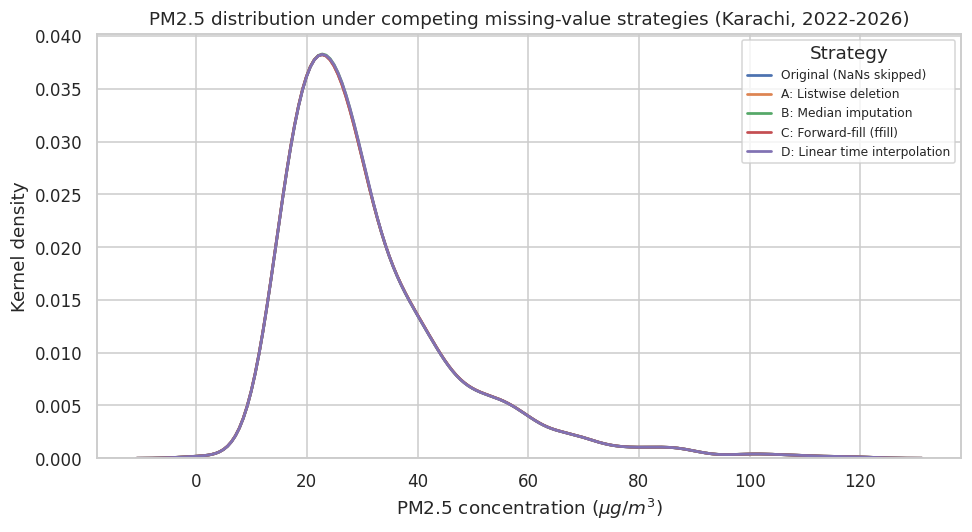

In [ ]:
# Visual check: do the imputed distributions still look like the original?
fig, ax = plt.subplots(figsize=(9, 5))
for name, s in strategies.items():
    sns.kdeplot(s.dropna(), label=name, ax=ax, linewidth=1.8)
ax.set_title("PM2.5 distribution under competing missing-value strategies (Karachi, 2022-2026)")
ax.set_xlabel(r"PM2.5 concentration ($\mu g/m^3$)")
ax.set_ylabel("Kernel density")
ax.legend(title="Strategy", fontsize=8)
plt.tight_layout()
plt.show()

**2.4 Interpretation.**

*Which strategy preserves the distribution best?* All four are nearly indistinguishable here — the mean
moves by less than 0.01 µg/m³ and the standard deviation by less than 0.02 µg/m³ — because only 0.231%
of `pm2_5` is missing. With so few gaps the choice is almost cosmetic, and the honest finding is that
**the method barely matters at this missingness rate**. Mechanically, though, they differ:

- **Median imputation** pulls three observations onto the exact centre of the distribution, so it very
  slightly *shrinks* the standard deviation (15.898 → 15.881). At high missingness this artificial spike
  at the median would distort the shape badly and falsely narrow every confidence interval built on it.
- **Forward-fill leaves all 3 NaNs unfilled**, because the gaps are at the *start* of the series and there
  is no earlier value to carry forward. This is a real trap: the code runs without error and silently
  does nothing. We therefore also show linear interpolation with `limit_direction="both"`, which fills
  from the nearest valid neighbour in either direction.
- **Listwise deletion** loses 4 rows (1,298 → 1,294) and drops the pollutant readings that *did* exist on
  2022-08-04 just because `us_aqi` was absent that day.

*Does listwise deletion risk selection bias?* Yes, and the mechanism is the important part. Deletion is
only safe when data are Missing Completely At Random. Environmental sensors fail non-randomly: extreme
smog loads the optical chamber, power cuts cluster with peak grid stress, and heavy rain or dust storms
knock out telemetry. If outages coincide with severe pollution episodes, the missingness is Missing Not
At Random — the probability of a value being absent depends on the value itself. Dropping those rows
systematically deletes the **worst** days, biasing the mean downward and the apparent safety of the city
upward. The measured air then looks cleaner precisely when it was most dangerous, which is the direction
of error most likely to harm exposed residents. In this dataset the gaps are start-of-record warm-up
rather than smog-driven, so we do not observe that bias — but that has to be *checked*, not assumed.

### Question 3: Outlier Handling — Mean/SD vs. IQR

In [ ]:
# 3.1 - Two competing upper-tail rules on the RAW pm2_5 column.
pm_clean = air["pm2_5"].dropna()

# Method A: non-resistant, mean + 3s (equivalently Z > 3)
mean_pm, sd_pm = pm_clean.mean(), pm_clean.std()
thr_A = mean_pm + 3 * sd_pm
out_A = pm_clean[pm_clean > thr_A]

# Method B: resistant, Tukey's Q3 + 1.5*IQR
q1, q3 = pm_clean.quantile([0.25, 0.75])
iqr = q3 - q1
thr_B = q3 + 1.5 * iqr
out_B = pm_clean[pm_clean > thr_B]

summary = pd.DataFrame({
    "Rule":               ["A: Mean + 3s", "B: Q3 + 1.5 x IQR"],
    "Centre":             [mean_pm, pm_clean.median()],
    "Spread":             [sd_pm, iqr],
    "Upper threshold (ug/m3)": [thr_A, thr_B],
    "Days flagged":       [len(out_A), len(out_B)],
    "% of record":        [100*len(out_A)/len(pm_clean), 100*len(out_B)/len(pm_clean)],
})
summary.round(3)

,Rule,Centre,Spread,Upper threshold (ug/m3),Days flagged,% of record
0,A: Mean + 3s,31.145,15.898,78.839,28,2.162
1,B: Q3 + 1.5 x IQR,26.871,16.440,61.674,65,5.019


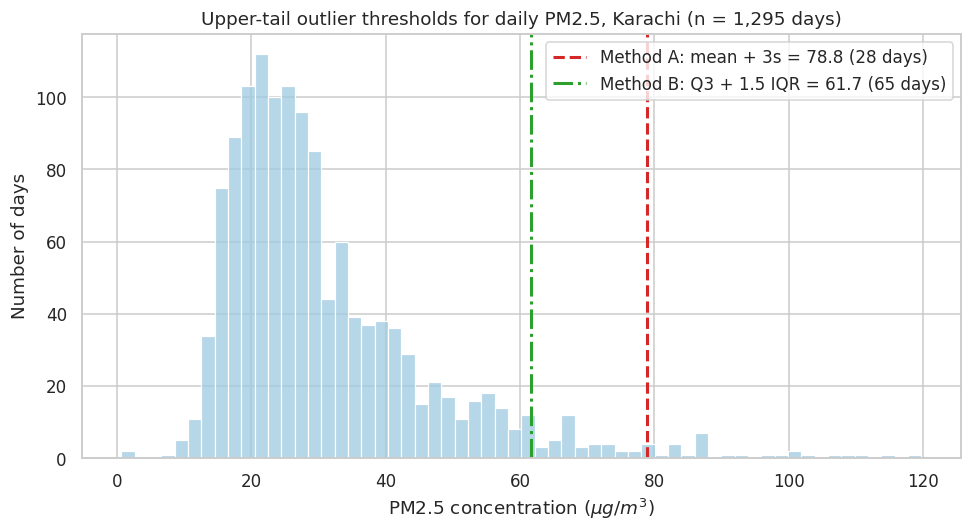

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(pm_clean, bins=60, color="#9ecae1", ax=ax)
ax.axvline(thr_A, color="#d62728", ls="--", lw=2,
           label=f"Method A: mean + 3s = {thr_A:,.1f} ({len(out_A)} days)")
ax.axvline(thr_B, color="#2ca02c", ls="-.", lw=2,
           label=f"Method B: Q3 + 1.5 IQR = {thr_B:,.1f} ({len(out_B)} days)")
ax.set_title("Upper-tail outlier thresholds for daily PM2.5, Karachi (n = 1,295 days)")
ax.set_xlabel(r"PM2.5 concentration ($\mu g/m^3$)")
ax.set_ylabel("Number of days")
ax.legend()
plt.tight_layout()
plt.show()

**3.2 Interpretation — why Method A flags fewer days.**

Method A flags **28** days above 78.84 µg/m³; Method B flags **65** days above 61.67 µg/m³. The gap is not
a tuning accident, it is structural.

The mean and standard deviation are **non-resistant**: every observation enters the formula, and the SD
enters it *squared*. A single 119.8 µg/m³ smog day contributes $(119.8 - 31.1)^2 \approx 7{,}870$ to the sum
of squared deviations, roughly 31 times the contribution of a typical day sitting 16 µg/m³ from the mean.
So the extreme day inflates $s$, and since the threshold is $\bar{x} + 3s$, **the outlier pushes the very
boundary that is supposed to catch it further out**. The detection rule is contaminated by the thing it
is detecting. Add a genuine winter smog cluster and $s$ rises again, the fence moves further right again,
and moderately bad days that *were* above the line fall back under it — this is the masking effect.
(Swamping is the mirror image: one huge value can also drag the mean up enough that ordinary low days
start looking anomalously far below it.)

The IQR rule is **resistant**: $Q_1$, the median and $Q_3$ are order statistics. Replacing the worst smog
day with a value ten times larger does not move them at all, because rank position is unchanged. Its
breakdown point is 25% per tail, versus effectively $1/n$ for the mean. That is exactly why a resistant
rule catches the 37 additional moderately-polluted days that Method A masks — and in a public-health
dispatch system, those are the days where an advisory could still have prevented exposure.

### Question 4: Attribute Transformation (Logarithmic Rescaling)

CO minimum          : 59.92 ug/m3  (strictly positive -> plain log is valid)
Skewness raw CO     : 1.121
Skewness log(CO)    : 0.075


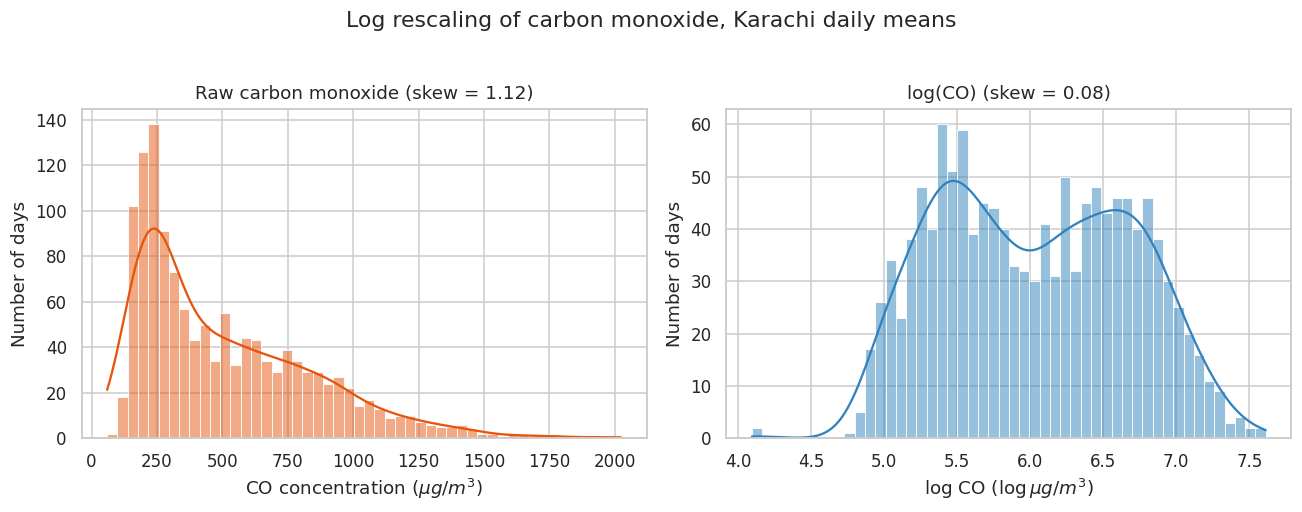

In [ ]:
# 4.1 / 4.2 / 4.3 - raw CO, then log-transformed CO
co_raw = air["carbon_monoxide"].dropna()
log_CO = np.log(co_raw)                 # safe: min(CO) > 0
air["log_CO"] = np.log(air["carbon_monoxide"])

skew_raw, skew_log = stats.skew(co_raw), stats.skew(log_CO)
print(f"CO minimum          : {co_raw.min():,.2f} ug/m3  (strictly positive -> plain log is valid)")
print(f"Skewness raw CO     : {skew_raw:,.3f}")
print(f"Skewness log(CO)    : {skew_log:,.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(co_raw, bins=50, kde=True, color="#e6550d", ax=axes[0])
axes[0].set_title(f"Raw carbon monoxide (skew = {skew_raw:.2f})")
axes[0].set_xlabel(r"CO concentration ($\mu g/m^3$)")
axes[0].set_ylabel("Number of days")

sns.histplot(log_CO, bins=50, kde=True, color="#3182bd", ax=axes[1])
axes[1].set_title(f"log(CO) (skew = {skew_log:.2f})")
axes[1].set_xlabel(r"log CO ($\log \mu g/m^3$)")
axes[1].set_ylabel("Number of days")
fig.suptitle("Log rescaling of carbon monoxide, Karachi daily means", y=1.03)
plt.tight_layout()
plt.show()

Dust minimum: 0.00 ug/m3
Skewness raw dust   : 2.584
Skewness log1p(dust): -0.322


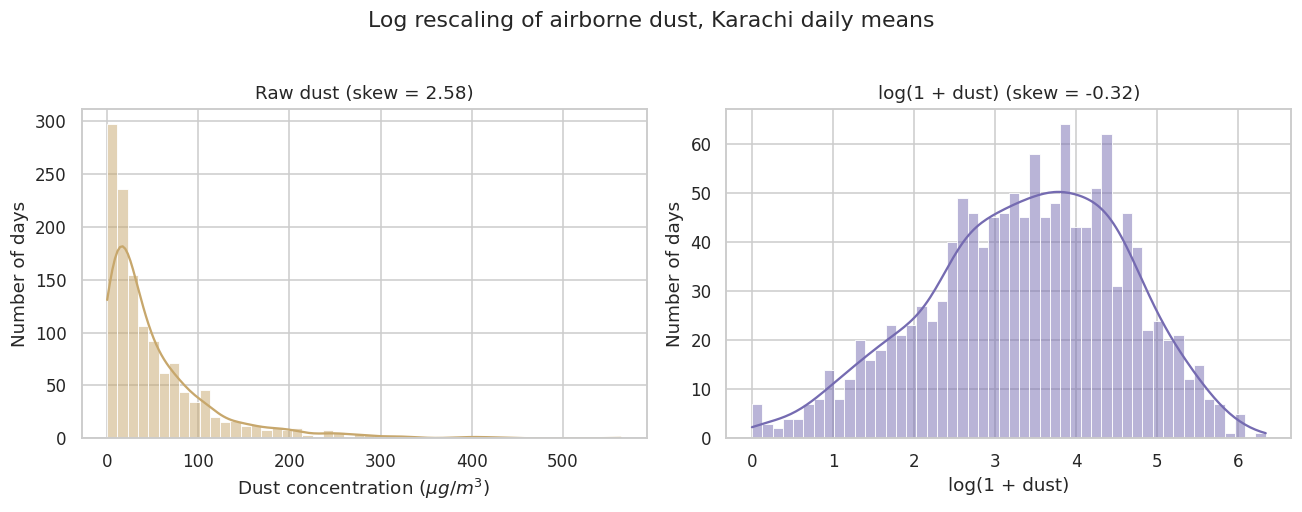

In [ ]:
# 4.5 - repeat on a second right-skewed variable: dust.
dust = air["dust"].dropna()
print(f"Dust minimum: {dust.min():,.2f} ug/m3")   # exactly 0 -> log(0) = -inf, so use log1p
log_dust = np.log1p(dust)
air["log_dust"] = np.log1p(air["dust"])

skew_d, skew_ld = stats.skew(dust), stats.skew(log_dust)
print(f"Skewness raw dust   : {skew_d:,.3f}")
print(f"Skewness log1p(dust): {skew_ld:,.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(dust, bins=50, kde=True, color="#c7a76c", ax=axes[0])
axes[0].set_title(f"Raw dust (skew = {skew_d:.2f})")
axes[0].set_xlabel(r"Dust concentration ($\mu g/m^3$)")
axes[0].set_ylabel("Number of days")

sns.histplot(log_dust, bins=50, kde=True, color="#756bb1", ax=axes[1])
axes[1].set_title(f"log(1 + dust) (skew = {skew_ld:.2f})")
axes[1].set_xlabel("log(1 + dust)")
axes[1].set_ylabel("Number of days")
fig.suptitle("Log rescaling of airborne dust, Karachi daily means", y=1.03)
plt.tight_layout()
plt.show()

**4.4 Interpretation.**

*How the logarithm compresses the tail.* The log is a monotone, concave function, so it preserves the
ordering of days while shrinking distances at the top of the range far more than at the bottom. In
multiplicative terms, log turns *equal ratios* into *equal distances*: the step from 100 to 200 µg/m³ and
the step from 1,000 to 2,000 µg/m³ both become $\log 2 \approx 0.69$. A doubling near the peak, which
dominated the raw variance, now costs exactly as much as a doubling near the floor. Carbon monoxide's
skewness falls from **+1.121** to **+0.075**, i.e. from strongly right-skewed to essentially symmetric,
and the log-scale histogram becomes close to a bell shape (the raw variable is approximately log-normal).
Dust goes from **+2.584** to **−0.322** under `log1p` — note it slightly *overshoots* into mild left skew,
because the many near-zero dust days get stretched apart at the bottom of the scale. Dust has an exact
minimum of 0.00 µg/m³, so `np.log` would return $-\infty$ and silently poison every downstream statistic;
`log1p` is the correct choice.

*Why transform instead of dropping industrial emission records?* Because those records are not errors,
they are the phenomenon. A 2,023 µg/m³ CO day is a real emission episode and is exactly the observation a
public-health model needs to learn from; deleting it is a data-quality claim we have no evidence for, and
it biases every estimate toward a cleaner city than the one people actually breathe. Transformation is
also reversible — we can always exponentiate back to physical units — while deletion is not. Log rescaling
buys the symmetry and stabilised variance that parametric methods assume *without* discarding evidence,
so no episode is erased from the record.

### Question 5: Discretization (Equal-Width vs. Equal-Frequency vs. Domain Bins)

In [ ]:
aqi = air["us_aqi"].dropna()
labels3 = ["Low Hazard", "Moderate Hazard", "Severe Hazard"]

# 5.1 - Equal-width: split the raw range into 3 equal intervals
ew = pd.cut(aqi, bins=3, labels=labels3)
ew_edges = pd.cut(aqi, bins=3).cat.categories

# 5.2 - Equal-frequency: 33rd / 67th percentiles
ef = pd.qcut(aqi, q=3, labels=labels3)
ef_edges = pd.qcut(aqi, q=3).cat.categories

# 5.3 - Third option: domain-driven US EPA cut-points (<=50 Good, 51-100 Moderate, >100 Unhealthy)
epa = pd.cut(aqi, bins=[-np.inf, 50, 100, np.inf], labels=labels3)

print("Equal-width edges     :", list(ew_edges))
print("Equal-frequency edges :", list(ef_edges))
print("EPA policy edges      : (-inf, 50], (50, 100], (100, inf]")

counts = pd.DataFrame({
    "Equal-width": ew.value_counts().reindex(labels3),
    "Equal-frequency": ef.value_counts().reindex(labels3),
    "EPA domain cut-points": epa.value_counts().reindex(labels3),
})
counts

Equal-width edges     : [Interval(15.301, 81.875, closed='right'), Interval(81.875, 148.25, closed='right'), Interval(148.25, 214.625, closed='right')]
Equal-frequency edges : [Interval(15.499, 74.042, closed='right'), Interval(74.042, 96.708, closed='right'), Interval(96.708, 214.625, closed='right')]
EPA policy edges      : (-inf, 50], (50, 100], (100, inf]


,Equal-width,Equal-frequency,EPA domain cut-points
us_aqi,,,
Low Hazard,628,432,13
Moderate Hazard,560,431,897
Severe Hazard,106,431,384


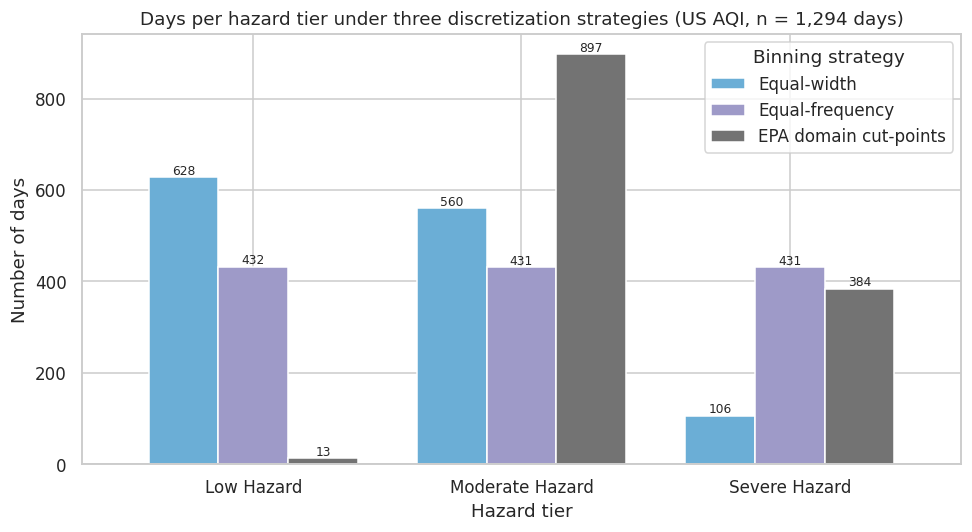

In [ ]:
ax = counts.plot(kind="bar", figsize=(9, 5), width=0.78,
                 color=["#6baed6", "#9e9ac8", "#737373"])
ax.set_title("Days per hazard tier under three discretization strategies (US AQI, n = 1,294 days)")
ax.set_xlabel("Hazard tier")
ax.set_ylabel("Number of days")
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Binning strategy")
for container in ax.containers:
    ax.bar_label(container, fontsize=8)
plt.tight_layout()
plt.show()

**5.4 Interpretation.**

*Why equal-width bins go lopsided under skew.* Equal-width binning uses only two numbers, the minimum and
the maximum, and ignores the density in between. Karachi's AQI runs from 15.50 to 214.62, so each bin is
66.4 index points wide regardless of how many days actually live there. Because the distribution is
right-skewed, the mass piles into the lower bins: **628 / 560 / 106** days. The "Severe" bin covers a third
of the numeric range but only **8.2%** of the record, and had the maximum been a single freak 400-AQI day,
the top bin would have been nearly empty while almost every day collapsed into "Low". The bin edges are
hostage to the extremes.

*Which is more actionable for emergency advisories?* It depends on what the tier is for, and the honest
answer is that neither of the statistical methods is ideal:

- **Equal-frequency** guarantees a workable operational caseload — **432 / 431 / 431** days, a fixed
  one-third of days in the top tier — which suits a fixed-capacity response team that can only dispatch so
  many advisories a year. But its cut-points (74.04 and 96.71) are defined *relative to Karachi's own
  polluted baseline*. On a hypothetically clean year it would still label a third of days "Severe", and on
  a catastrophic year it would still label two-thirds "safe". It normalises whatever is normal.
- **Equal-width** is transparent and stable in physical units, but as shown it is driven by the extremes.
- **The EPA domain cut-points** (50 / 100) are the defensible choice for *health* advisories, because the
  boundaries are anchored to external toxicological evidence about when breathing becomes harmful, not to
  the sample. They reveal what relative binning hides: only **13** of 1,294 days are genuinely "Good", 897
  are Moderate, and **384 days (29.7%)** exceed AQI 100 — that is, Karachi spends roughly three days in ten
  above the unhealthy threshold.

So: equal-frequency for resource scheduling, EPA cut-points for deciding when to warn the public. We would
dispatch on the EPA tiers.

---
## Section B — Urban Water Consumption & Climate Stress
### Question 6: Data Integration & Stacking (Vertical Concatenation)

In [ ]:
# The file actually contains 23 households, N01-N26 with N06, N16 and N22 absent.
print(sorted(water["NodeID"].unique()))

# 6.1 - split into two "regional log files" so that every node is covered exactly once
node_num = water["NodeID"].str.extract(r"N(\d+)").astype(int)[0]
zone_north = water[node_num <= 12].copy()   # N01-N12
zone_south = water[node_num >= 13].copy()   # N13-N26

print(f"\nzone_north: {zone_north.shape} | nodes {sorted(zone_north['NodeID'].unique())}")
print(f"zone_south: {zone_south.shape} | nodes {sorted(zone_south['NodeID'].unique())}")

['N01', 'N02', 'N03', 'N04', 'N05', 'N07', 'N08', 'N09', 'N10', 'N11', 'N12', 'N13', 'N14', 'N15', 'N17', 'N18', 'N19', 'N20', 'N21', 'N23', 'N24', 'N25', 'N26']

zone_north: (2437, 7) | nodes ['N01', 'N02', 'N03', 'N04', 'N05', 'N07', 'N08', 'N09', 'N10', 'N11', 'N12']
zone_south: (1526, 7) | nodes ['N13', 'N14', 'N15', 'N17', 'N18', 'N19', 'N20', 'N21', 'N23', 'N24', 'N25', 'N26']


In [ ]:
# 6.2 - vertical stacking
stacked = pd.concat([zone_north, zone_south], ignore_index=True)

# 6.3 - verification: dimensions, columns, and content
checks = {
    "row counts match":      len(stacked) == len(water),
    "column counts match":   stacked.shape[1] == water.shape[1],
    "column names identical": list(stacked.columns) == list(water.columns),
    "no rows duplicated":    not stacked.duplicated().any(),
    "same set of nodes":     set(stacked["NodeID"]) == set(water["NodeID"]),
    "same total water volume": np.isclose(stacked["wu_lpcd"].sum(), water["wu_lpcd"].sum()),
}
print(f"original: {water.shape}   stacked: {stacked.shape}\n")
for k, v in checks.items():
    print(f"{'PASS' if v else 'FAIL'}  {k}")

# strongest check: same rows in the same order after sorting
assert stacked.sort_values(["NodeID", "Date"]).reset_index(drop=True).equals(
       water.sort_values(["NodeID", "Date"]).reset_index(drop=True))
print("\nPASS  row-by-row equality after sorting")

original: (3963, 7)   stacked: (3963, 7)

PASS  row counts match
PASS  column counts match
PASS  column names identical
PASS  no rows duplicated
PASS  same set of nodes
PASS  same total water volume

PASS  row-by-row equality after sorting


**6.4 Conceptual distinction — stacking vs. merging.**

**Stacking (vertical concatenation)** adds *observations*. The two inputs share the same schema and
describe the same kind of entity, so the columns stay fixed and the row count grows:
$n_1 + n_2$ rows, $k$ columns. It answers "we have more of the same measurements". Nothing is matched;
the only risks are schema mismatch, duplicate rows if the sources overlap, and inconsistent units or
category spellings across files.

**Merging / augmenting (horizontal join)** adds *attributes*. The inputs describe the same entities from
different angles and are aligned on a **key**, so the row count ideally stays fixed while the columns grow:
$n$ rows, $k_1 + k_2 - (\text{keys})$ columns. Here the risks are key-level: non-unique keys silently
producing a many-to-many row explosion, and unmatched keys becoming NaN (or vanishing, on an inner join).

*When would we merge horizontally on this water data?* Whenever we need a variable the daily log does not
contain. Examples: joining a **household attributes table** on `NodeID` (members, income band, storage tank
capacity, neighbourhood) to test whether per-capita use differs by economic status; joining the
**air-quality file** on `Date` to align water demand with heat and pollution; or joining a
**tanker-supply schedule** on `NodeID` + `Date` to see whether consumption spikes follow delivery days.
The `city_info.csv` file is exactly this shape — a lookup table to be joined, not stacked.

### Question 7: Spatial & Temporal Aggregation

In [ ]:
# 7.1 - per-household (NodeID) summary, including a resistant spread measure (IQR)
iqr_fn = lambda s: s.quantile(0.75) - s.quantile(0.25)

by_node = (water.groupby("NodeID")["wu_lpcd"]
                .agg(Days="count", Mean="mean", Median="median", Std="std", IQR=iqr_fn)
                .sort_values("Median"))
by_node.round(2)

,Days,Mean,Median,Std,IQR
NodeID,,,,,
N26,206,22.280,20.910,8.790,9.720
N15,21,29.430,27.920,12.430,19.350
N25,105,43.650,40.690,25.540,31.810
N18,105,53.940,40.790,25.530,37.910
N13,185,62.590,58.840,21.550,25.210
N21,98,66.660,63.610,20.210,22.090
N17,178,78.020,71.140,27.200,34.790
N19,241,74.780,71.680,22.160,26.720
N08,95,75.660,76.250,26.470,30.990


In [ ]:
# 7.2 - monthly averages of demand and temperature
by_month = (water.groupby("Month")
                 .agg(mean_wu=("wu_lpcd", "mean"),
                      mean_maxT=("maxDailyT", "mean"),
                      n_days=("wu_lpcd", "size")))
by_month.round(2)

,mean_wu,mean_maxT,n_days
Month,,,
1,130.480,73.610,380
2,140.470,83.370,436
3,151.280,88.620,398
4,156.050,91.850,323
5,205.060,93.520,255
6,183.230,92.300,232
7,153.230,87.340,215
8,139.610,86.340,280
9,114.440,87.520,307


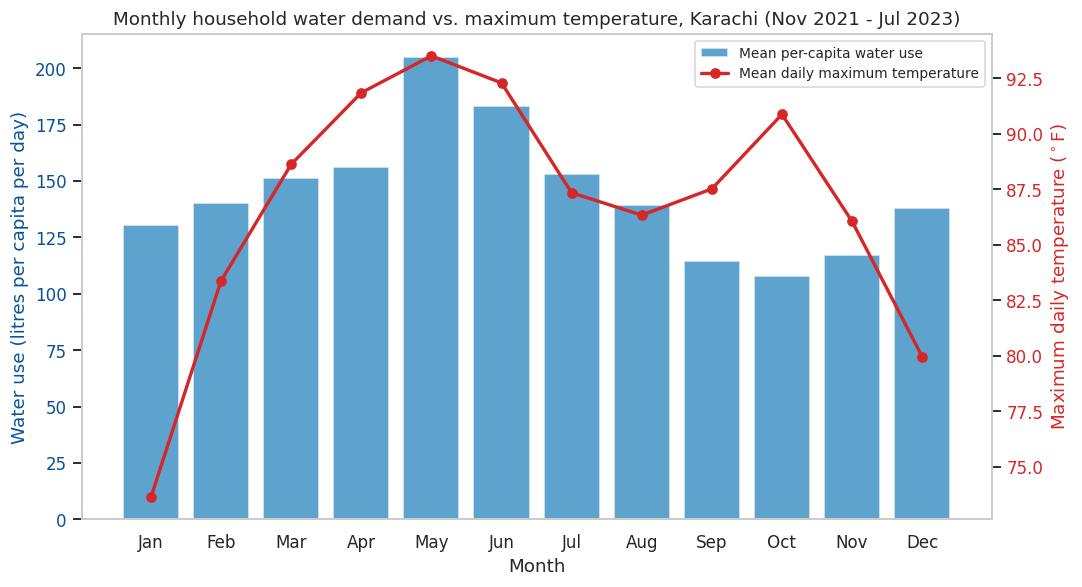

In [ ]:
# 7.3 - dual-axis plot: monthly water demand vs monthly maximum temperature
month_names = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

fig, ax1 = plt.subplots(figsize=(10, 5.5))
ax1.bar(by_month.index, by_month["mean_wu"], color="#4292c6", alpha=0.85,
        label="Mean per-capita water use")
ax1.set_xlabel("Month")
ax1.set_ylabel("Water use (litres per capita per day)", color="#08519c")
ax1.tick_params(axis="y", labelcolor="#08519c")
ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(month_names)
ax1.grid(False)

ax2 = ax1.twinx()
ax2.plot(by_month.index, by_month["mean_maxT"], color="#d62728", marker="o", lw=2.2,
         label="Mean daily maximum temperature")
ax2.set_ylabel(r"Maximum daily temperature ($^\circ$F)", color="#d62728")
ax2.tick_params(axis="y", labelcolor="#d62728")
ax2.grid(False)

lines = ax1.get_legend_handles_labels()[0] + ax2.get_legend_handles_labels()[0]
labels = ax1.get_legend_handles_labels()[1] + ax2.get_legend_handles_labels()[1]
ax1.legend(lines, labels, loc="upper right", fontsize=9)
plt.title("Monthly household water demand vs. maximum temperature, Karachi (Nov 2021 - Jul 2023)")
plt.tight_layout()
plt.show()

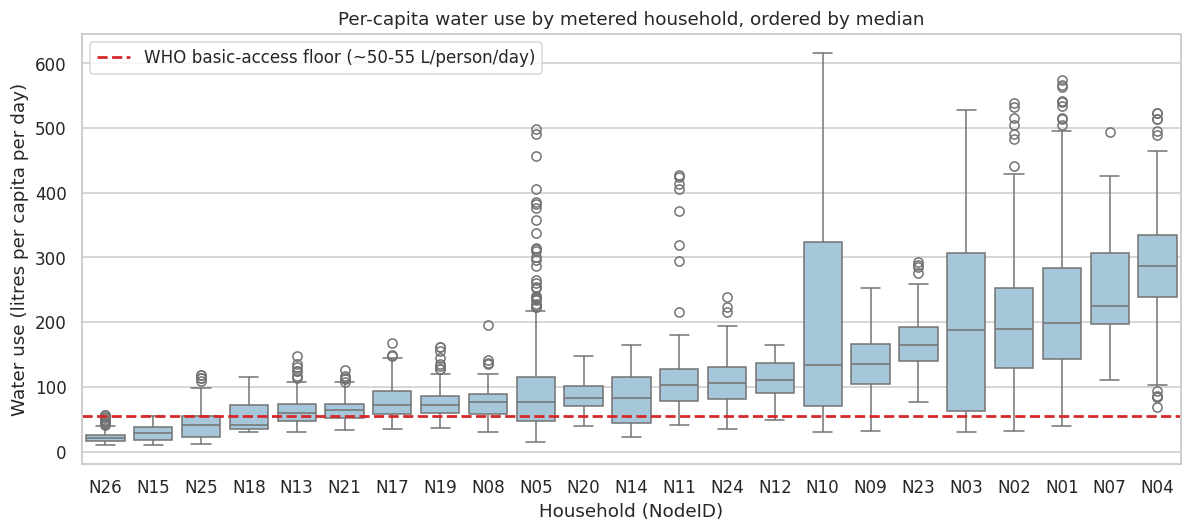

In [ ]:
# Distribution of demand per household, ordered by median - shows who is water-poor
order = by_node.index
fig, ax = plt.subplots(figsize=(11, 5))
sns.boxplot(data=water, x="NodeID", y="wu_lpcd", order=order, color="#9ecae1", ax=ax)
ax.axhline(54.6, color="#d62728", ls="--", lw=1.8,
           label="WHO basic-access floor (~50-55 L/person/day)")
ax.set_title("Per-capita water use by metered household, ordered by median")
ax.set_xlabel("Household (NodeID)")
ax.set_ylabel("Water use (litres per capita per day)")
ax.legend()
plt.tight_layout()
plt.show()

**7.4 Interpretation.**

*Seasonal trajectory.* Temperature climbs from a January trough of **73.6 °F** to a May peak of **93.5 °F**.
Water demand rises with it — 130.5 L/capita/day in January to a **May peak of 205.1** — but the two series
do not stay locked together. Demand peaks in **May**, one month *before* the June temperature plateau, then
falls steeply through the hottest-but-most-humid months to a **September–October trough of ~108–114
L/capita/day** while maximum temperatures are still 87–91 °F. So the peak does not lag heat, it slightly
**leads** it, and the autumn collapse in demand happens while it is still hot.

That pattern is hard to explain with thermal comfort alone, and the most plausible reading for Karachi is
that **autumn demand is supply-constrained rather than desire-constrained**: households cannot draw what
is not delivered. Two caveats we should not paper over. First, the record spans Nov 2021 – Jul 2023, so
each calendar month pools an uneven mix of one or two years — May and June here are single-year
observations. Second, households enter and leave the study at different dates, so a monthly mean is
partly a composition effect: the *set* of households being averaged changes month to month.

*Which households suffer acute deficit?* Using the WHO basic-access benchmark of roughly 50–55
L/capita/day, the clearly deficient households are **N26 (median 20.9)**, **N15 (27.9)**, **N25 (40.7)**,
**N18 (40.8)** and **N13 (58.8)** — N26 is using under half the basic-access floor, and roughly one
thirteenth of what N04 (median 286.2) consumes. The inequality is enormous. Two cautions before treating
this as a ranking of need: **N15 has only 21 days of data** and N12 only 30, so those medians are fragile;
and low measured flow can mean either poor supply or heavy reliance on unmetered sources (tanker
deliveries, shared standpipes, stored water), which the flowmeter cannot see. Households like **N03 and
N10** show huge IQRs (244 and 253 L) — not low on average, but wildly *intermittent*, which is its own
form of water insecurity.

### Question 8: Bivariate Correlation & Scatter Plot Analysis

In [ ]:
# Drop the 10 rows where maxDailyT is missing (all N04, July 2023)
wt = water.dropna(subset=["maxDailyT"])
print(f"Rows used: {len(wt):,} of {len(water):,}  (10 missing temperatures excluded)")

r,   p_r   = stats.pearsonr(wt["maxDailyT"], wt["wu_lpcd"])
rho, p_rho = stats.spearmanr(wt["maxDailyT"], wt["wu_lpcd"])
print(f"Pearson  r   = {r: .4f}   (p = {p_r:.3g})   r^2 = {r**2:.4f}")
print(f"Spearman rho = {rho: .4f}   (p = {p_rho:.3g})")

Rows used: 3,953 of 3,963  (10 missing temperatures excluded)
Pearson  r   =  0.0903   (p = 1.28e-08)   r^2 = 0.0082
Spearman rho =  0.0946   (p = 2.55e-09)


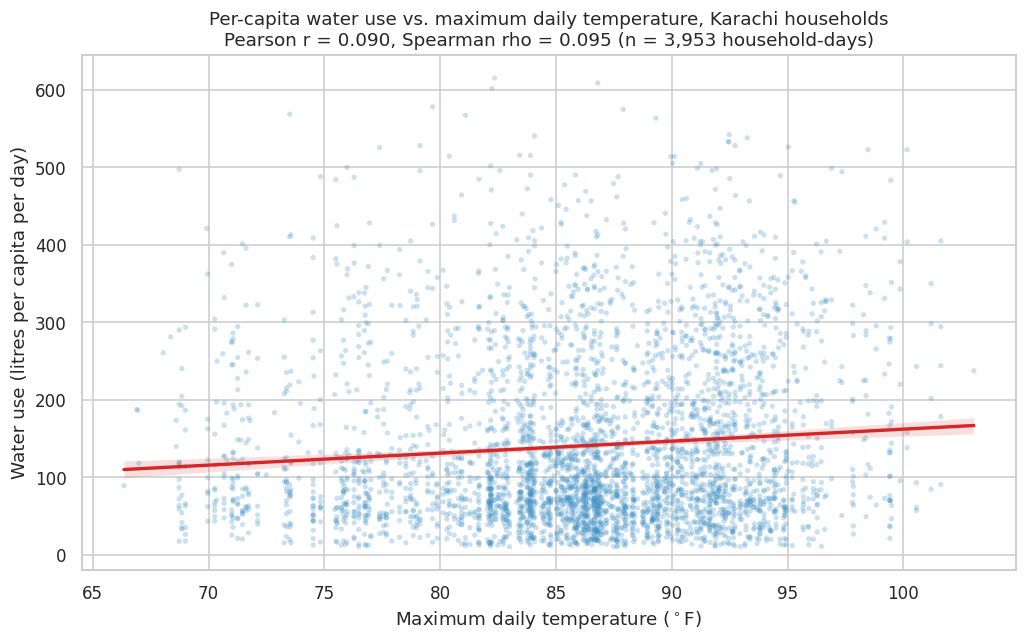

In [ ]:
fig, ax = plt.subplots(figsize=(9.5, 6))
sns.regplot(data=wt, x="maxDailyT", y="wu_lpcd", ax=ax,
            scatter_kws=dict(s=12, alpha=0.28, color="#4292c6", edgecolor="none"),
            line_kws=dict(color="#d62728", lw=2.2))
ax.set_title("Per-capita water use vs. maximum daily temperature, Karachi households\n"
             f"Pearson r = {r:.3f}, Spearman rho = {rho:.3f} (n = {len(wt):,} household-days)")
ax.set_xlabel(r"Maximum daily temperature ($^\circ$F)")
ax.set_ylabel("Water use (litres per capita per day)")
plt.tight_layout()
plt.show()

**8.3 Interpretation.**

Both coefficients are **positive but very weak**: Pearson $r = 0.090$, Spearman $\rho = 0.095$. The close
agreement between the two tells us the relationship is not a monotone pattern being hidden by outliers or
curvature — it is simply weak. The $p$-values ($1.3\times10^{-8}$ and $2.5\times10^{-9}$) are tiny, which is
a statement about *precision, not importance*: with $n = 3{,}953$ even a trivial association clears
significance. The effect size is what matters, and $r^2 = 0.008$ means **temperature explains about 0.8%
of the variation in per-capita water use**. Roughly 99% of the variation lies elsewhere — overwhelmingly
in *which household* we are looking at, as Q7 showed (medians span 20.9 to 286.2 L).

*Does this mean heatwaves cause water overuse?* No, on two separate grounds.

1. **Causation is not established by correlation**, and here the correlation is negligible anyway. The
   plausible confounders all move together with temperature: season, month of the study, school and work
   calendars, Ramadan timing, monsoon humidity, and above all the **utility's own supply schedule** — if
   KWSB curtails supply in the dry season, consumption falls when heat rises, which would actively *mask*
   any behavioural heat response. Agricultural or industrial draw upstream works the same way. What we
   measure is water **received and used**, which is supply ∩ demand, not demand.
2. **The observations are not independent.** These are 23 households measured repeatedly over up to 453
   days each, so a single household's habits are counted hundreds of times. Pooling them inflates the
   apparent sample size and mixes a *within-household* effect (does this family use more water on hot
   days?) with a *between-household* effect (do high-use families live in hotter months of the record?).
   Answering the causal question properly needs a within-household design — a fixed-effects or
   mixed-effects model with `NodeID` as a grouping factor — not a pooled correlation.

### Question 9: Categorical Encoding (One-Hot Dummy Variables)

**9.1 Why integer coding corrupts the model.**

Coding Mon = 1 … Sun = 7 takes a **nominal** variable and hands the algorithm an **interval/ratio** one.
Three false claims get smuggled in:

1. **A false order** — Sunday > Monday. Weekday labels have no rank; the ordering is a calendar
   convention, and it is not even a stable one (many calendars start the week on Sunday, and Pakistan's
   working week is Mon–Fri, so "7" is not the end of anything meaningful).
2. **False equal spacing** — the model assumes Wed − Tue = Sun − Sat = 1 unit of "day-ness".
3. **False arithmetic** — a linear model fits a single coefficient $\beta$ and predicts
   $\hat{y} = \alpha + \beta \cdot \text{day}$, forcing consumption to move by the *same* amount for every
   one-step move along the week. It can express "water use rises steadily from Monday to Sunday" but
   cannot express "Friday and Sunday are high, everything else is flat" — which, given Pakistan's
   Friday congregational prayers and Mon–Fri work week, is exactly the shape we would expect.

The arbitrariness is the giveaway: relabelling the same days Sun = 1 … Sat = 7 changes the fitted
coefficients and predictions, even though no information in the data has changed.

One-hot encoding fixes this by giving each day its own free parameter, so the model can place the seven
days in any pattern the data supports, with no order or spacing assumed.

In [ ]:
# 9.2 - seven binary indicator flags
dow_order = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
dummies = pd.get_dummies(water["DayofWeek"], prefix="is").astype(int)
dummies = dummies[[f"is_{d}" for d in dow_order]]        # keep calendar order for readability

water_encoded = pd.concat([water, dummies], axis=1)

# 9.3 - first 5 rows of the encoded dataframe
print("Shape after encoding:", water_encoded.shape)
print("Row sums (each row must have exactly one 1):", set(dummies.sum(axis=1)))
water_encoded.head()

Shape after encoding: (3963, 14)
Row sums (each row must have exactly one 1): {1}


,Date,NodeID,wu_lpcd,maxDailyT,DayofWeek,WN,Month,is_Mon,is_Tue,is_Wed,is_Thu,is_Fri,is_Sat,is_Sun
0,2021-11-24,N01,147.469,84.311,Wed,47,11,0,0,1,0,0,0,0
1,2021-11-25,N01,53.993,87.103,Thu,47,11,0,0,0,1,0,0,0
2,2021-11-26,N01,344.103,87.079,Fri,48,11,0,0,0,0,1,0,0
3,2021-11-28,N01,75.202,86.167,Sun,48,11,0,0,0,0,0,0,1
4,2021-12-01,N01,255.306,85.990,Wed,48,12,0,0,1,0,0,0,0


*Practical note:* all seven columns sum to 1 in every row, so in a regression with an intercept the full
set is perfectly collinear (the "dummy variable trap"). For modelling we would drop one level as the
reference category — `pd.get_dummies(..., drop_first=True)` — but the question asks for all seven flags,
so they are all shown here.

---
## Section C — Inferential Statistics & Assumption Diagnostics
### Question 10: Weekday vs. Weekend Water Demand

**10.1 Hypotheses.** Let $\mu_{we}$ and $\mu_{wd}$ be mean per-capita consumption on weekend
(Sat–Sun) and weekday (Mon–Fri) household-days.

$$H_0:\ \mu_{we} = \mu_{wd} \qquad\text{(no difference in mean consumption)}$$
$$H_1:\ \mu_{we} \neq \mu_{wd} \qquad\text{(two-tailed, as specified)}$$

We note the tension in the brief: the water board's claim ("higher on weekends") is *directional* and
would warrant a one-tailed test, but the question explicitly asks for a two-tailed comparison. We run it
two-tailed as instructed, which is also the more conservative choice, and interpret the direction from the
sign of the statistic.

In [ ]:
weekend = water.loc[water["DayofWeek"].isin(["Sat", "Sun"]), "wu_lpcd"]
weekday = water.loc[~water["DayofWeek"].isin(["Sat", "Sun"]), "wu_lpcd"]

desc = pd.DataFrame({
    "n":      [len(weekend), len(weekday)],
    "Mean":   [weekend.mean(), weekday.mean()],
    "Median": [weekend.median(), weekday.median()],
    "Std":    [weekend.std(), weekday.std()],
}, index=["Weekend (Sat-Sun)", "Weekday (Mon-Fri)"])
desc.round(3)

,n,Mean,Median,Std
Weekend (Sat-Sun),1125,135.523,97.438,108.012
Weekday (Mon-Fri),2838,143.770,104.510,110.903


Shapiro-Wilk weekend: W = 0.8545, p = 5.8e-31
Shapiro-Wilk weekday: W = 0.8797, p = 2.15e-42


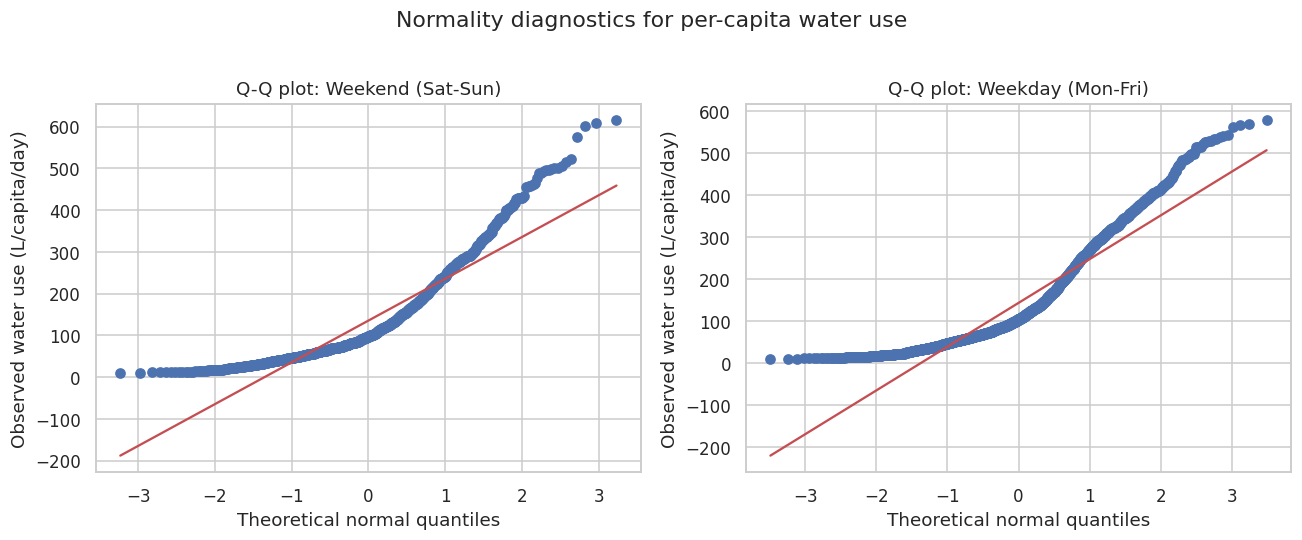

In [ ]:
# 10.2a - Normality: Shapiro-Wilk + Q-Q plots
sw_we = stats.shapiro(weekend)
sw_wd = stats.shapiro(weekday)
print(f"Shapiro-Wilk weekend: W = {sw_we.statistic:.4f}, p = {sw_we.pvalue:.3g}")
print(f"Shapiro-Wilk weekday: W = {sw_wd.statistic:.4f}, p = {sw_wd.pvalue:.3g}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
for ax, sample, name in zip(axes, [weekend, weekday], ["Weekend (Sat-Sun)", "Weekday (Mon-Fri)"]):
    stats.probplot(sample, dist="norm", plot=ax)
    ax.set_title(f"Q-Q plot: {name}")
    ax.set_xlabel("Theoretical normal quantiles")
    ax.set_ylabel("Observed water use (L/capita/day)")
fig.suptitle("Normality diagnostics for per-capita water use", y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# 10.2b - Homoscedasticity: Levene's test (median-centred, the robust 'Brown-Forsythe' variant)
lev = stats.levene(weekend, weekday, center="median")
print(f"Levene (median-centred): W = {lev.statistic:.4f}, p = {lev.pvalue:.4f}")
print(f"Variance ratio (weekday / weekend) = {weekday.var()/weekend.var():.3f}")

Levene (median-centred): W = 3.7479, p = 0.0529
Variance ratio (weekday / weekend) = 1.054


In [ ]:
# 10.3 / 10.4 - run all three so the decision rule is transparent
t_pool  = stats.ttest_ind(weekend, weekday, equal_var=True)
t_welch = stats.ttest_ind(weekend, weekday, equal_var=False)
u_test  = stats.mannwhitneyu(weekend, weekday, alternative="two-sided")

results = pd.DataFrame({
    "Test":      ["Student's t (pooled)", "Welch's t", "Mann-Whitney U"],
    "Statistic": [t_pool.statistic, t_welch.statistic, u_test.statistic],
    "df":        [t_pool.df, t_welch.df, np.nan],
    "p-value":   [t_pool.pvalue, t_welch.pvalue, u_test.pvalue],
    "Decision at alpha = 0.05": ["Reject H0" if p < 0.05 else "Fail to reject H0"
                                 for p in [t_pool.pvalue, t_welch.pvalue, u_test.pvalue]],
})
display(results.round(4))

# Effect size (Cohen's d) - significance is not importance
n1, n2 = len(weekend), len(weekday)
s_pool = np.sqrt(((n1-1)*weekend.var() + (n2-1)*weekday.var()) / (n1+n2-2))
d = (weekend.mean() - weekday.mean()) / s_pool
print(f"Difference in means = {weekend.mean()-weekday.mean():+.2f} L/capita/day")
print(f"Cohen's d = {d:.4f}  (|d| < 0.2 is conventionally a negligible effect)")

,Test,Statistic,df,p-value,Decision at alpha = 0.05
0,Student's t (pooled),-2.126,"3,961.000",0.034,Reject H0
1,Welch's t,-2.151,"2,113.517",0.032,Reject H0
2,Mann-Whitney U,"1,527,269.000",NaN,0.033,Reject H0


Difference in means = -8.25 L/capita/day
Cohen's d = -0.0749  (|d| < 0.2 is conventionally a negligible effect)


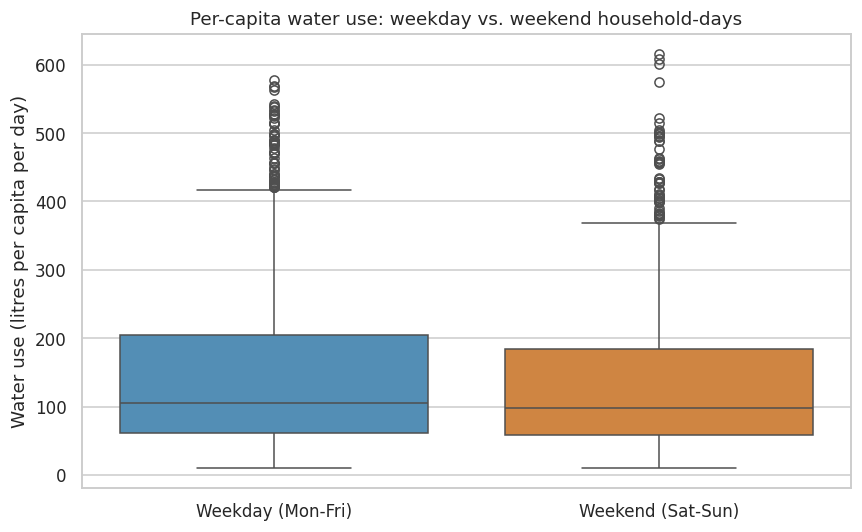

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=water.assign(Group=np.where(water["DayofWeek"].isin(["Sat","Sun"]),
                                             "Weekend (Sat-Sun)", "Weekday (Mon-Fri)")),
            x="Group", y="wu_lpcd", palette=["#4292c6", "#e6842a"], hue="Group",
            legend=False, ax=ax)
ax.set_title("Per-capita water use: weekday vs. weekend household-days")
ax.set_xlabel("")
ax.set_ylabel("Water use (litres per capita per day)")
plt.tight_layout()
plt.show()

**10.5 Interpretation.**

**Assumptions.** Normality fails decisively in both groups (Shapiro–Wilk $W = 0.855$, $p \approx 5.8
\times 10^{-31}$ for weekends; $W = 0.880$, $p \approx 2.2\times10^{-42}$ for weekdays). The Q-Q plots show
the classic right-skew signature: points hugging the line through the middle then curving sharply upward
in the upper tail. Levene's test gives $W = 3.748$, $p = 0.0529$ — just above $\alpha = 0.05$, so we do not
formally reject equal variances, but it is close enough that we should not lean on the pooled-variance
assumption. Following the decision rule, **Mann–Whitney U is the primary test**, with Welch's $t$ as the
parametric backup.

**Result.** All three agree. Mann–Whitney $U = 1{,}527{,}269$, $p = 0.0333$; Welch's $t(2113.5) = -2.151$,
$p = 0.0316$; pooled $t(3961) = -2.126$, $p = 0.0336$. At $\alpha = 0.05$ we **reject $H_0$** — but note the
**sign**. Weekend mean consumption is **135.52** L/capita/day against a weekday mean of **143.77**: weekends
are about **8.25 L/capita/day lower**, not higher. The water board's stated claim is *contradicted in
direction* by the data. And the effect is tiny: Cohen's $d = -0.075$, well under the 0.2 threshold for a
"small" effect, and $p$ sits just below 0.05 only because $n = 3{,}963$. A difference of 8 L against a
between-household spread of 20 to 286 L is operationally negligible.

**Policy implication.** There is no evidence for weekend-peaked residential demand, so **re-scheduling
distribution to load extra supply onto Saturdays and Sundays is not justified** by this data. The variance
that actually matters is *spatial and seasonal*, not weekly: the household-to-household gap (Q7) is more
than an order of magnitude larger than the weekday/weekend gap, and the May-versus-October swing is ~90 L.
Equity-focused reallocation toward chronically deficient households (N26, N15, N25, N18) would do far more
than any day-of-week rescheduling.

**Caveats.** Same independence problem as Q8 — repeated daily measurements from 23 households are not
3,963 independent observations, so the true standard error is larger than the test assumes and this
marginal $p = 0.033$ would very likely cross back above 0.05 under a clustered or mixed-effects analysis.
Also, in Pakistan Friday carries congregational prayers and is a partial-rest day for many households, so
the Sat–Sun / Mon–Fri split may not cleanly separate "rest days" from "work days" at all.

**10.6 Why the brief offers three different tests.** Each test buys robustness at the price of assumptions,
and the choice is a decision tree rather than a menu:

| Test | Assumes | Cost of using it when assumptions hold | Use when |
|---|---|---|---|
| Student's pooled $t$ | Normality (or large $n$ via CLT), **equal variances**, independence | Most powerful of the three | Both assumptions pass |
| Welch's $t$ | Normality/CLT, independence — **not** equal variances | Loses a little power and fractional df | Levene fails, or variances look unequal |
| Mann–Whitney U | Independence and (for a strict location claim) similar distribution shapes | ~95% of $t$'s power under normality | Normality fails badly, or data are ordinal |

Two subtleties worth stating. First, with $n_1 = 1{,}125$ and $n_2 = 2{,}838$ the Central Limit Theorem makes
the $t$-tests fairly robust to non-normality anyway — Shapiro–Wilk is also hypersensitive at large $n$, where
it detects deviations too small to matter, so we did not treat its rejection as automatically fatal. That is
precisely why all three tests are reported and why they agree. Second, Mann–Whitney tests stochastic
dominance, not means; with these right-skewed distributions the medians (97.4 vs 104.5) tell the same story
as the means, so the conclusion is not an artefact of which centre we chose.

### Question 11: One-Sample Test on Climate Stress & $t$ vs. $Z$ Diagnostics

**11.1 Hypotheses.** With $\mu_0 = 80.0\,^\circ$F:

$$H_0:\ \mu \le 80.0\,^\circ\text{F} \qquad H_1:\ \mu > 80.0\,^\circ\text{F} \quad\text{(one-tailed, upper)}$$

In [ ]:
temp = water["maxDailyT"].dropna()     # 10 missing values (all N04, July 2023) excluded
n, xbar, s = len(temp), temp.mean(), temp.std(ddof=1)
mu0 = 80.0
se = s / np.sqrt(n)

print(f"n     = {n:,}       <- note: 3,953, not the 3,963 quoted in the question")
print(f"x-bar = {xbar:.4f} degF")
print(f"s     = {s:.4f} degF   (sample SD, ddof = 1)")
print(f"SE    = {se:.4f} degF")

t_stat, p_val = stats.ttest_1samp(temp, popmean=mu0, alternative="greater")
t_crit = stats.t.ppf(0.99, df=n-1)
print(f"\nt({n-1}) = {t_stat:.3f}   one-tailed p = {p_val:.3g}")
print(f"Critical t at alpha = 0.01, df = {n-1}: {t_crit:.4f}")

# How different would a Z-test have been? (see 11.3)
z_stat = (xbar - mu0) / se
print(f"\nFor comparison, z = {z_stat:.3f}; "
      f"t critical {t_crit:.4f} vs z critical {stats.norm.ppf(0.99):.4f} "
      f"(difference = {t_crit - stats.norm.ppf(0.99):.5f})")

n     = 3,953       <- note: 3,953, not the 3,963 quoted in the question
x-bar = 86.2714 degF
s     = 6.4239 degF   (sample SD, ddof = 1)
SE    = 0.1022 degF

t(3952) = 61.381   one-tailed p = 0
Critical t at alpha = 0.01, df = 3952: 2.3273

For comparison, z = 61.381; t critical 2.3273 vs z critical 2.3263 (difference = 0.00094)


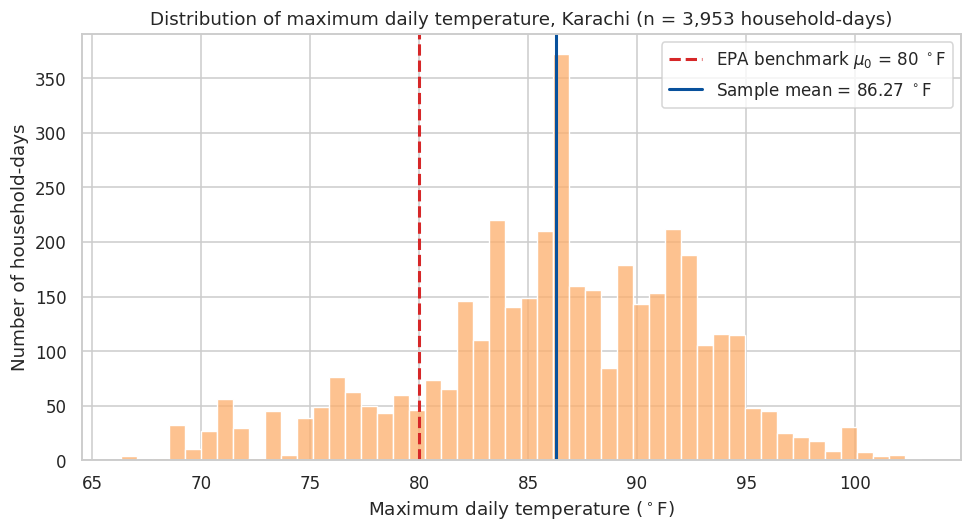

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(temp, bins=50, color="#fdae6b", ax=ax)
ax.axvline(mu0, color="#d62728", ls="--", lw=2, label=rf"EPA benchmark $\mu_0$ = {mu0:.0f} $^\circ$F")
ax.axvline(xbar, color="#08519c", lw=2, label=rf"Sample mean = {xbar:.2f} $^\circ$F")
ax.set_title(f"Distribution of maximum daily temperature, Karachi (n = {n:,} household-days)")
ax.set_xlabel(r"Maximum daily temperature ($^\circ$F)")
ax.set_ylabel("Number of household-days")
ax.legend()
plt.tight_layout()
plt.show()

**11.3 Conceptual diagnostic — why "n > 30, so use Z" is flawed.**

The student has mixed up two different assumptions. The choice between $Z$ and $t$ is **not** decided by
sample size; it is decided by **whether the population standard deviation $\sigma$ is known**.

- If $\sigma$ is known, $\dfrac{\bar{X}-\mu_0}{\sigma/\sqrt{n}}$ has exactly one random quantity in it,
  $\bar{X}$, so the statistic is exactly standard normal (given normal data).
- If $\sigma$ is unknown, we must estimate it with the sample SD $s$, and the statistic
  $\dfrac{\bar{X}-\mu_0}{s/\sqrt{n}}$ now has **two** random quantities, $\bar{X}$ *and* $s$, both varying
  from sample to sample. That extra estimation error makes the ratio more variable than a standard normal.
  Gosset showed in 1908 that it follows Student's $t$ with $n-1$ degrees of freedom — a distribution with
  heavier tails, which widens critical values to keep the true Type I error rate at $\alpha$. Using $Z$ when
  $\sigma$ is estimated understates the uncertainty and produces confidence intervals that are too narrow
  and $p$-values that are too small.

So $t$ is the **mathematically correct** distribution here for a structural reason — $\sigma$ is unknown and
$s = 6.424\,^\circ$F is an estimate — regardless of whether $n$ is 15 or 15,000. The $n > 30$ rule is a
separate, unrelated heuristic about when the **Central Limit Theorem** makes the sampling distribution of
$\bar{X}$ approximately normal despite non-normal raw data.

Where the student has a *practical* half-point: as $n \to \infty$, $s \to \sigma$ and $t_{n-1}$ converges to
$N(0,1)$. At $df = 3{,}952$ the two are numerically almost identical — the one-tailed critical value at
$\alpha = 0.01$ is $2.3273$ for $t$ versus $2.3263$ for $Z$, a difference of about 0.0009. The numerical
answer would be the same to three decimals. But "the difference has become negligible" is not the same claim
as "the $Z$-test is required", and the justification given (sample size) is the wrong reason. The $t$-test is
correct at every $n$ and simply *becomes* the $Z$-test in the limit, so there is never a reason to switch.

**11.4 Result and conclusion.**

$\bar{x} = 86.271\,^\circ$F, $s = 6.424\,^\circ$F, $n = 3{,}953$ (the 10 missing temperatures, all from
household N04 in July 2023, are excluded — so $n$ is 3,953, not the 3,963 stated in the question).

$$t = \frac{86.271 - 80.0}{6.424/\sqrt{3953}} = 61.38, \qquad df = 3952, \qquad p \approx 0 \;(\text{underflows to } 0.0)$$

Since $t = 61.38$ vastly exceeds the critical value $t_{0.99,\,3952} = 2.327$ and $p \ll 0.01$, we **reject
$H_0$ at $\alpha = 0.01$**. There is overwhelming evidence that mean maximum daily temperature in Karachi
exceeds the 80 °F benchmark; the observed mean sits **6.27 °F above** it, which is an effect of real physical
size and not merely a significant one ($d \approx 0.98$).

The usual caveats hold. `maxDailyT` is a city-level daily series repeated across households, so the effective
number of independent days is far below 3,953 and the true standard error is understated — though with a
statistic of 61 the conclusion is in no danger. More substantively, an "average" threshold is a strange
benchmark for heat stress: the health risk lives in the **upper tail** (the record reaches 103 °F), so a
policy test on exceedance frequency would be more useful than one on the mean.

---
## Section D — Social Impact & Ethical Reflection
### Question 12: Algorithmic Bias & the "Loop of Neglect"

### 12.1 Reflection

An algorithmic “loop of neglect” is formed in social policy when non-resistant statistics, like the mean and the standard deviation, are used. Extreme values have a significant influence on these statistics. A few very high or very low values inflate the mean and standard deviation, which pushes the cutoff further out. Households in real need then fall inside the cutoff and are never flagged, and a policy model does not treat them as a priority. They could be given less water delivery, repairs or other assistance. The situation remains unfavorable, and the next dataset still reflects low water use. The model reads this as evidence that they didn't need very much assistance. The same injustice is repeated.

As data scientists we are ethically responsible to know what the numbers mean before selecting a method. The median and IQR are useful in this study as they do not suffer the effect of extreme values. They provide a more representative description of a typical household and the typical distribution of water use. The figure in the notebook indicates that some households are using much less than the basic-access level in the WHO guidelines. If we use only mean and standard deviation, this problem may be concealed.

Resistant statistics are not necessarily fair, however. Extreme values can be genuine indicators of wealth, crisis, or inequity, and should not be just thrown out the window. Resistant and non-resistant summaries should both be reported, outliers investigated and the effect on the policy result explained. It would also be beneficial to review missing households, unmetered water sources, sample size, and measurement bias. It is not only our responsibility to create an accurate model, but to make sure that disadvantaged people remain not invisible in our choices of statistics.

---
## References

- Nitiraj, K., & Jagadish, T. (2026). *Air Quality Dataset for Karachi (2022-08-01 to 2026-02-18)* [Dataset]. Zenodo. https://doi.org/10.5281/zenodo.18673762
- Khan, H. F. (2024). *Karachi household water use (daily resolution)* [Dataset]. HydroShare. http://www.hydroshare.org/resource/dfdc2e29fa984595a0252f26c9dad013
- Khan, H. F., Arif, M. A., Intikhab, S., & Arshad, S. A. (2023). Quantifying Household Water Use and Its Determinants in Low-Income, Water-Scarce Households in Karachi. *Water*, 15(19), 3400.